<a href="https://colab.research.google.com/github/VAISHNAVI7558/Adv-Python/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
path ='/content/Cars.csv'

## **File Reading**

In [78]:
import warnings
warnings.filterwarnings("ignore")

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [80]:
df = pd.read_csv(path ,keep_default_na=False , na_values=['' , 'NA'] )

 ## **Basic Data Quality Checks**

In [81]:
df.head()

,id1,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,1,Toyota,Tercel,Small,7.8,9.8,11.8,32,37,Driver only,...,5,162,94,65,36,24.0,11.0,2055,non-USA,Toyota Tercel
1,2,Lexus,ES300,Midsize,27.5,28.0,28.4,18,24,Driver only,...,5,188,103,70,40,27.5,14.0,3510,non-USA,Lexus ES300
2,3,Subaru,Legacy,Compact,16.3,19.5,22.7,23,30,Driver only,...,5,179,102,67,37,27.0,14.0,3085,non-USA,Subaru Legacy
3,4,Chevrolet,Lumina_APV,Van,14.7,16.3,18.0,18,23,None,...,7,178,110,74,44,30.5,NaN,3715,USA,Chevrolet Lumina_APV
4,5,Chevrolet,Cavalier,Compact,8.5,13.4,18.3,25,36,None,...,5,182,101,66,38,25.0,13.0,2490,USA,Chevrolet Cavalier


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8556 entries, 0 to 8555
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id1                 8556 non-null   int64  
 1   Manufacturer        8556 non-null   object 
 2   Model               8556 non-null   object 
 3   Type                8556 non-null   object 
 4   Min.Price           8556 non-null   float64
 5   Price               8556 non-null   float64
 6   Max.Price           8556 non-null   float64
 7   MPG.city            8556 non-null   int64  
 8   MPG.highway         8556 non-null   int64  
 9   AirBags             8185 non-null   object 
 10  DriveTrain          8556 non-null   object 
 11  Cylinders           8556 non-null   object 
 12  EngineSize          8556 non-null   float64
 13  Horsepower          8556 non-null   int64  
 14  RPM                 8556 non-null   int64  
 15  Rev.per.mile        8556 non-null   int64  
 16  Man.tr

In [83]:
n = df.isnull().sum()
n[n>0]

,0
AirBags,371
Rear.seat.room,180
Luggage.room,1025


In [84]:
df.duplicated().sum()

np.int64(0)

## **SEPRATION OF X & Y**

In [85]:
df.columns

Index(['id1', 'Manufacturer', 'Model', 'Type', 'Min.Price', 'Price',
       'Max.Price', 'MPG.city', 'MPG.highway', 'AirBags', 'DriveTrain',
       'Cylinders', 'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile',
       'Man.trans.avail', 'Fuel.tank.capacity', 'Passengers', 'Length',
       'Wheelbase', 'Width', 'Turn.circle', 'Rear.seat.room', 'Luggage.room',
       'Weight', 'Origin', 'Make'],
      dtype='object')

In [86]:
x = df.drop(['id1','Weight'] , axis = 1)
y = df['Weight']

In [87]:
x.head()

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Fuel.tank.capacity,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Origin,Make
0,Toyota,Tercel,Small,7.8,9.8,11.8,32,37,Driver only,Front,...,11.9,5,162,94,65,36,24.0,11.0,non-USA,Toyota Tercel
1,Lexus,ES300,Midsize,27.5,28.0,28.4,18,24,Driver only,Front,...,18.5,5,188,103,70,40,27.5,14.0,non-USA,Lexus ES300
2,Subaru,Legacy,Compact,16.3,19.5,22.7,23,30,Driver only,4WD,...,15.9,5,179,102,67,37,27.0,14.0,non-USA,Subaru Legacy
3,Chevrolet,Lumina_APV,Van,14.7,16.3,18.0,18,23,None,Front,...,20.0,7,178,110,74,44,30.5,NaN,USA,Chevrolet Lumina_APV
4,Chevrolet,Cavalier,Compact,8.5,13.4,18.3,25,36,None,Front,...,15.2,5,182,101,66,38,25.0,13.0,USA,Chevrolet Cavalier


In [88]:
y.head()

,Weight
0,2055
1,3510
2,3085
3,3715
4,2490


## **CATEGORICAL & NUMERICAL DATA SEPERATION**

In [89]:
cat = x.columns[x.dtypes == 'object']
num = x.columns[x.dtypes != 'object']

In [90]:
print(cat)
print("----------------")
print(num)

Index(['Manufacturer', 'Model', 'Type', 'AirBags', 'DriveTrain', 'Cylinders',
       'Man.trans.avail', 'Origin', 'Make'],
      dtype='object')
----------------
Index(['Min.Price', 'Price', 'Max.Price', 'MPG.city', 'MPG.highway',
       'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Fuel.tank.capacity',
       'Passengers', 'Length', 'Wheelbase', 'Width', 'Turn.circle',
       'Rear.seat.room', 'Luggage.room'],
      dtype='object')


In [91]:
x['Model'].unique()

array(['Tercel', 'ES300', 'Legacy', 'Lumina_APV', 'Cavalier', 'Eurovan',
       'Festiva', 'Vision', 'Diamante', 'Justy', 'Grand_Prix', '100',
       'LeSabre', 'Century', '900', 'Eighty-Eight', 'Lumina', 'Metro',
       'Stealth', 'SL', 'Altima', 'Roadmaster', 'Cutlass_Ciera', '240',
       'Maxima', 'Caprice', 'Sentra', 'Previa', 'Legend', 'Spirit',
       'Taurus', 'Shadow', '90', 'Cougar', 'Fox', 'Firebird', 'Quest',
       'Camry', 'Sonata', 'Tempo', 'Dynasty', 'Bonneville', 'Corvette',
       'LeMans', 'Civic', 'SC300', 'Caravan', 'Continental', 'Protege',
       'Capri', 'Probe', '323', 'Town_Car', '850', 'Concorde', 'Escort',
       'Silhouette', 'Riviera', 'Accord', 'LeBaron', 'Achieva', '190E',
       'Swift', 'Corsica', 'Seville', 'Passat', 'Colt', 'Elantra',
       'Celica', 'Crown_Victoria', 'RX-7', 'Astro', 'Aerostar', 'Loyale',
       'Storm', '626', 'Q45', 'Excel', 'Summit', 'Integra', 'Mirage',
       'Sunbird', 'Mustang', 'DeVille', 'Scoupe', '535i', 'MPV', 'Camaro',


## **CREATE PIPELINE**

In [92]:
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [93]:
num_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('onehot' , OrdinalEncoder())
])

## **Combine all Pipelines**

In [94]:
pre = ColumnTransformer([
    ('num' , num_pipeline , num),
    ('cat' , cat_pipeline , cat)
])

In [95]:
pre

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['Min.Price', 'Price', 'Max.Price', 'MPG.city', 'MPG.highway',
       'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Fuel.tank.capacity',
       'Passengers', 'Length', 'Wheelbase', 'Width', 'Turn.circle',
       'Rear.seat.room', 'Luggage.room'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot', OrdinalEncoder())]),
                                 Index(['Manufacturer', 'Model', 'Type', 'AirBags', 'DriveTrain', 'Cylinders',
       'Man.trans.avail', 'Origin', 'Make'],
      dtype='object'))])

## **APPLY TO DATA**

In [96]:
x_scaled = pre.fit_transform(x)

In [97]:
x_scaled

array([[-1.06513120e+00, -1.00862838e+00, -9.23020335e-01, ...,
         1.00000000e+00,  1.00000000e+00,  8.60000000e+01],
       [ 1.18186902e+00,  8.76793468e-01,  5.87973111e-01, ...,
         1.00000000e+00,  1.00000000e+00,  4.80000000e+01],
       [-9.56133433e-02, -3.76069249e-03,  6.91380121e-02, ...,
         1.00000000e+00,  1.00000000e+00,  8.00000000e+01],
       ...,
       [ 1.04499591e+00,  7.00682636e-01,  3.96823338e-01, ...,
         0.00000000e+00,  0.00000000e+00,  7.00000000e+00],
       [-1.01950683e+00, -1.09150407e+00, -1.09596537e+00, ...,
         1.00000000e+00,  0.00000000e+00,  7.50000000e+01],
       [-7.11542338e-01, -8.22158089e-01, -8.77508484e-01, ...,
         1.00000000e+00,  1.00000000e+00,  5.50000000e+01]])

In [98]:
x_scaled = pd.DataFrame(x_scaled , columns= x.columns)

In [99]:
x_scaled.head()

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Fuel.tank.capacity,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Origin,Make
0,-1.065131,-1.008628,-0.923020,1.680241,1.461275,-1.126873,-1.180752,-0.127721,2.370666,-1.443413,...,-1.046831,29.0,90.0,3.0,1.0,1.0,1.0,1.0,1.0,86.0
1,1.181869,0.876793,0.587973,-0.776170,-0.949254,0.330813,0.818523,-0.127721,-0.024507,0.558949,...,0.037908,15.0,37.0,2.0,1.0,1.0,3.0,1.0,1.0,48.0
2,-0.095613,-0.003761,0.069138,0.101120,0.163298,-0.446619,-0.249051,0.548139,-0.014358,-0.229860,...,0.037908,27.0,54.0,0.0,1.0,0.0,1.0,1.0,1.0,80.0
3,-0.278111,-0.335263,-0.358673,-0.776170,-1.134679,1.108245,0.527367,-0.803580,-1.313435,1.014032,...,0.037908,5.0,58.0,5.0,2.0,1.0,3.0,0.0,0.0,18.0
4,-0.985289,-0.635688,-0.331366,0.452036,1.275850,-0.446619,-0.637259,-0.127721,0.087133,-0.442232,...,-0.323672,5.0,21.0,0.0,2.0,1.0,1.0,1.0,0.0,14.0


## **Train Test Split**

In [100]:
from sklearn.model_selection  import train_test_split

In [101]:
x_train , x_test , y_train , y_test = train_test_split(x_scaled , y , test_size=0.2 , random_state=45)

In [102]:
print(x_train.shape , y_train.shape)
print(x_test.shape , y_test.shape  )

(6844, 26) (6844,)
(1712, 26) (1712,)


## **Create Architechture**

In [103]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [104]:
nn = Sequential()

## Add input layer
nn.add(Dense(units=300 , input_dim=x_train.shape[1]))

## Add hidden layer
nn.add(Dense(units=256 , activation='relu'))
nn.add(Dense(units=512 , activation='relu'))

## Add output layer
nn.add(Dense(units=1 , activation='linear'))
nn.compile(loss='mean_squared_error' , optimizer='adam')


In [105]:
nn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 300)            │         8,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        77,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,253 (848.64 KB)

 Trainable params: 217,253 (848.64 KB)

 Non-trainable params: 0 (0.00 B)

## **Model Compilation**

In [106]:
nn.compile(optimizer='adam' , loss='mse' , metrics=['mae'])

## **Model Fitting**

In [107]:
hist = nn.fit(x_train , y_train , epochs=50 , validation_split=0.2 )

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 3682939.0000 - mae: 1581.4966 - val_loss: 762427.7500 - val_mae: 682.2936
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 523911.5938 - mae: 550.4411 - val_loss: 198876.5625 - val_mae: 344.4386
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 159905.8750 - mae: 316.6933 - val_loss: 114236.2031 - val_mae: 266.0626
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 107518.5938 - mae: 259.8408 - val_loss: 95484.4844 - val_mae: 241.8285
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 94518.4844 - mae: 240.8445 - val_loss: 117139.3203 - val_mae: 277.6829
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 85557.9922 - mae: 231.3707 - val_loss: 70312.0781 - val_mae: 207.0448
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 74642.2266 - mae: 216.0319 - val_loss: 71189.0156 - val_mae: 216.1194
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 65280.9336 - mae: 20

## **Plot graph between loss and val_loss**

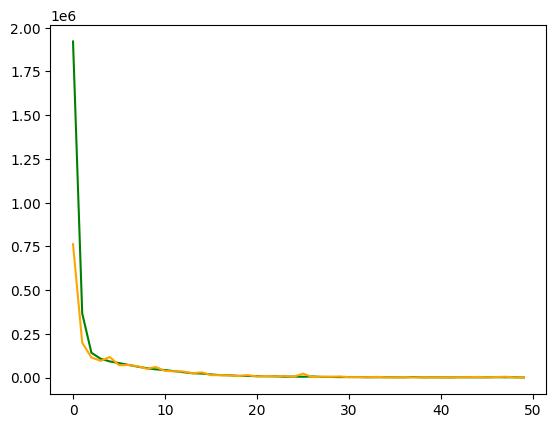

In [109]:
plt.plot(hist.history['loss'] , c= 'green')
plt.plot(hist.history['val_loss'] , c = 'orange')


## **Model evaluation**

In [111]:
from sklearn.metrics import (r2_score , mean_absolute_error , mean_squared_error , root_mean_squared_error)

In [113]:
def evaluate(model ,x , y):
  pred = model.predict(x)
  mae = mean_absolute_error(y , pred)
  mse = mean_squared_error(y , pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y , pred)

  print('MAE : ' , mae)
  print('MSE : ' , mse)
  print('RMSE : ' , rmse)
  print('R2 : ' , r2)

## Training Evaluation

In [114]:
evaluate(nn , x_train , y_train)

214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
MAE :  26.70789337158203
MSE :  865.8875732421875
RMSE :  29.42596766874774
R2 :  0.997477114200592


## Testing Evaluation

In [115]:
evaluate(nn , x_test , y_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE :  27.0357608795166
MSE :  881.5526733398438
RMSE :  29.69095271862868
R2 :  0.997588574886322


In [ ]:
## model is working good on training and testing . we can use this m